In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error


In [27]:
data = pd.read_csv("data/Salary_dataset.csv")
data

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [30]:
data.shape


(30, 3)

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [34]:
data["YearsExperience"].shape

(30,)

In [35]:
data["YearsExperience"].values.reshape(-1,1)

array([[ 1.2],
       [ 1.4],
       [ 1.6],
       [ 2.1],
       [ 2.3],
       [ 3. ],
       [ 3.1],
       [ 3.3],
       [ 3.3],
       [ 3.8],
       [ 4. ],
       [ 4.1],
       [ 4.1],
       [ 4.2],
       [ 4.6],
       [ 5. ],
       [ 5.2],
       [ 5.4],
       [ 6. ],
       [ 6.1],
       [ 6.9],
       [ 7.2],
       [ 8. ],
       [ 8.3],
       [ 8.8],
       [ 9.1],
       [ 9.6],
       [ 9.7],
       [10.4],
       [10.6]])

In [36]:
data.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

C:\Users\Rahavi ganeshan\AppData\Local\Temp\ipykernel_32000\983081318.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


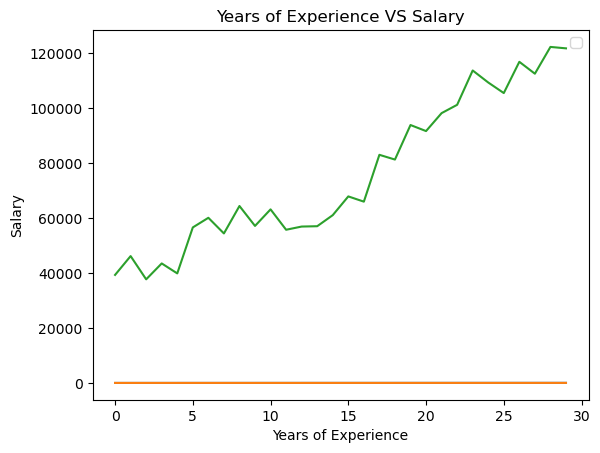

In [37]:
plt.plot(data)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience VS Salary")
plt.legend()
plt.show()

In [38]:

X=data[["YearsExperience"]]
Y=data["Salary"]




In [39]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state = 42
)

In [40]:
model = LinearRegression()

In [41]:
model.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred = model.predict(X_test)

In [46]:
r2 = r2_score(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
mse = mean_squared_error(Y_test,y_pred)

In [57]:
print("r2 : ",r2)
print("mean absolute error : ",mae)
print("mean squared error : ",mse)

r2 :  0.9024461774180498
mean absolute error :  6286.453830757745
mean squared error :  49830096.855908334


In [58]:
intercept = model.intercept_
coffecient = model.coef_[0]

print(intercept)
print(coffecient)

24380.20147947369
9423.81532303098


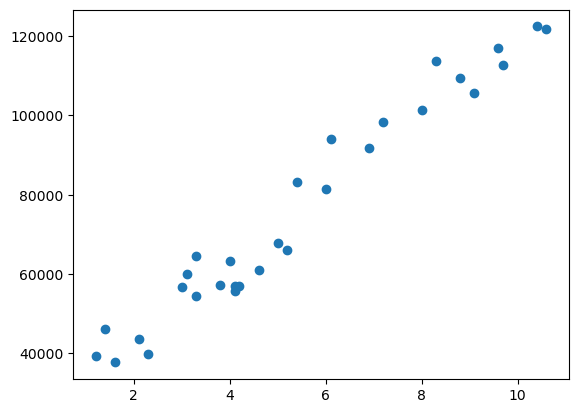

In [59]:
plt.scatter(X,Y,label="Actual Data")
plt.show()

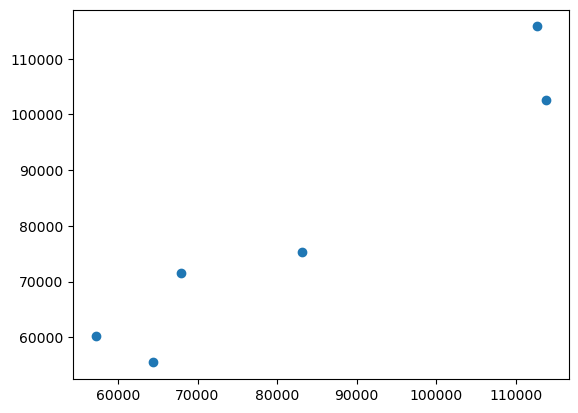

In [60]:
plt.scatter(Y_test,y_pred ,label="Test Vs Prdicted values")
plt.show()

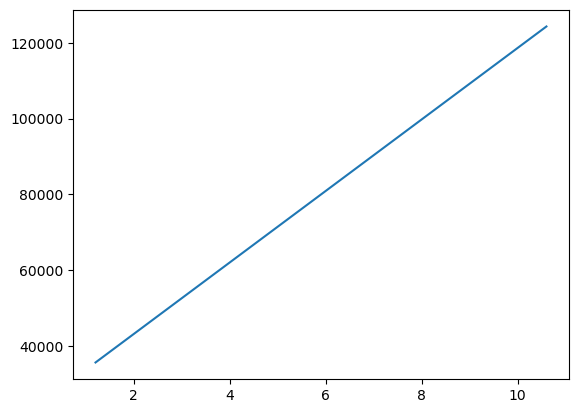

In [61]:
plt.plot(
    X,
    model.predict(X),
    label="Regression line"
)
plt.show()

In [62]:
comparison = pd.DataFrame({
    "Actual" : Y_test,
    "Predicted" : y_pred
})
comparison

,Actual,Predicted
27,112636.0,115791.210113
15,67939.0,71499.278095
23,113813.0,102597.868661
17,83089.0,75268.804224
8,64446.0,55478.792045
9,57190.0,60190.699707


In [63]:
#overfitting check

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_r2 = r2_score(Y_train,train_pred)
test_r2 = r2_score(Y_test,test_pred)

In [64]:
print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.9645401573418148
Testing R²: 0.9024461774180498


In [65]:
model.predict([[5]])

c:\Users\Rahavi ganeshan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([71499.27809463])